# <span style="color:red"> QTM 151 - Quiz 4 </span>

### Submit as an HTML file
### Quiz is open 11:30am to 12:20pm

In [16]:
# import necessary libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [30]:
import pandas as pd

reviews_df = pd.DataFrame({
    "id": [1, 2, 3, 4, 5],
    "location": ["newyork city", "los angeles", "newyork-city", "sanfrancisco", "los-angeles"],
    "reviews": [
        "The hotel was nice! Really nice service.",
        "I loved the location, but the rooms were not clean.",
        "The NICE staff helped me with my bags. Very nice people.",
        "Rooms were okay-ish; price was fair.",
        "Such a NICE place!!I would totally come again. employee"
    ]
})

reviews_df


,id,location,reviews
0,1,newyork city,The hotel was nice! Really nice service.
1,2,los angeles,"I loved the location, but the rooms were not c..."
2,3,newyork-city,The NICE staff helped me with my bags. Very ni...
3,4,sanfrancisco,Rooms were okay-ish; price was fair.
4,5,los-angeles,Such a NICE place!!I would totally come again....


In [9]:
#"New-York City"
#reviews_df['location'] = reviews_df['location'].str.replace("wrong", "right")

reviews_df["location"] = (reviews_df["location"].str.replace("newyork city", "New-York City", ).str.replace("newyork-city", "New-York City"))
reviews_df
#the function of regex=False is to treat the pattern as a literal string rather than a regular expression.

,id,location,reviews
0,1,New-York City,The hotel was nice! Really nice service.
1,2,los angeles,"I loved the location, but the rooms were not c..."
2,3,New-York City,The NICE staff helped me with my bags. Very ni...
3,4,sanfrancisco,Rooms were okay-ish; price was fair.
4,5,los angeles,Such a NICE place!! I would totally come again.


In [20]:
reviews_df2 = reviews_df["reviews"].str.contains("!+[A-Za-z]")
reviews_df2

0    False
1    False
2    False
3    False
4     True
Name: reviews, dtype: bool

In [25]:
# SOLUTION

answer = reviews_df["reviews"].str.findall("[Nn][Ii][Cc][Ee][Ss]?")

# [Nn][Ii][Cc][Ee][Ss]? match "NICE", "Nice", "nice", "Nices", "nices", etc.
#[Nn][Ii][Cc][Ee][Ss?] the "?" means the preceding character "S" can appear 0 or 1 time.

answer = answer[answer.str.len() > 0]
display(answer)

0    [nice, nice]
2    [NICE, nice]
4          [NICE]
Name: reviews, dtype: object

In [31]:
# SOLUTION

answer2 = reviews_df["reviews"].str.findall("[A-Za-z]+e\\b")


answer2 = answer2[answer2.str.len() > 0]
display(answer2)

0    [The, nice, nice, service]
1              [the, the, were]
2       [The, me, nice, people]
3                 [were, price]
4       [place, come, employee]
Name: reviews, dtype: object

In [36]:
reviews_df["tokens"] = reviews_df["reviews"].str.findall("[A-Za-z'-]+")
reviews_df["tokens"]


def lower_list(lst):
    out = []
    if not isinstance(lst, list):
        return tuple(out)
    for w in lst:
        out.append(w.lower())
    return tuple(out)

reviews_df["tokens"] = reviews_df["tokens"].apply(lower_list)
reviews_df["tokens"]

0       (the, hotel, was, nice, really, nice, service)
1    (i, loved, the, location, but, the, rooms, wer...
2    (the, nice, staff, helped, me, with, my, bags,...
3            (rooms, were, okay-ish, price, was, fair)
4    (such, a, nice, place, i, would, totally, come...
Name: tokens, dtype: object

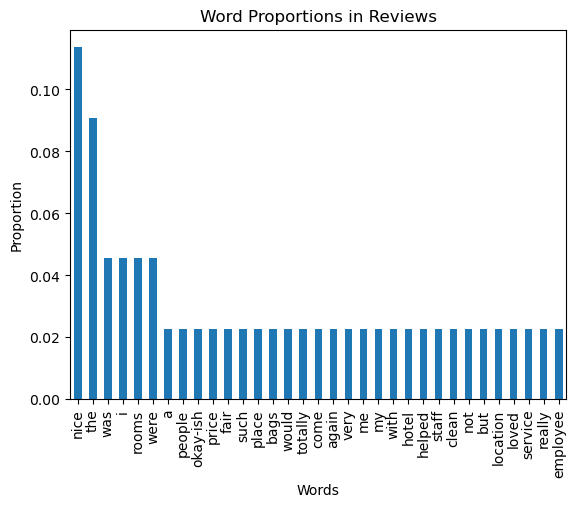

In [44]:
answer3 = reviews_df["tokens"].explode()
answer3


answer4 = answer3.value_counts(normalize = True)
answer4


answer4.plot(kind="bar")
plt.xlabel("Words")
plt.ylabel("Proportion")
plt.title("Word Proportions in Reviews")
plt.show()